In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ecommerce_data.csv', parse_dates=['date'])
print("Shape:", df.shape)
df.head()

Shape: (1000, 13)


,order_id,date,category,region,payment_method,unit_price,quantity,discount,revenue,customer_id,month,month_name,is_returned
0,ORD1000,2024-01-01,Clothing,East,COD,311,3,0.05,886.35,CUST272,1,Jan,0
1,ORD1001,2024-01-01,Sports,East,UPI,1841,3,0.00,5523.00,CUST178,1,Jan,0
2,ORD1002,2024-01-01,Home & Kitchen,South,Credit Card,4163,1,0.00,4163.00,CUST209,1,Jan,0
3,ORD1003,2024-01-02,Home & Kitchen,North,UPI,715,4,0.00,2860.00,CUST316,1,Jan,0
4,ORD1004,2024-01-02,Electronics,East,Credit Card,5338,4,0.00,21352.00,CUST205,1,Jan,1


In [2]:
# Get the month of every order
df['order_month'] = df['date'].dt.to_period('M')

# Find the FIRST purchase month for each customer
df['cohort_month'] = df.groupby('customer_id')['date'].transform('min').dt.to_period('M')

print(df[['customer_id', 'date', 'order_month', 'cohort_month']].head(10))

  customer_id       date order_month cohort_month
0     CUST272 2024-01-01     2024-01      2024-01
1     CUST178 2024-01-01     2024-01      2024-01
2     CUST209 2024-01-01     2024-01      2024-01
3     CUST316 2024-01-02     2024-01      2024-01
4     CUST205 2024-01-02     2024-01      2024-01
5     CUST146 2024-01-02     2024-01      2024-01
6     CUST280 2024-01-03     2024-01      2024-01
7     CUST163 2024-01-03     2024-01      2024-01
8     CUST345 2024-01-03     2024-01      2024-01
9     CUST343 2024-01-04     2024-01      2024-01


In [7]:
# How many months after first purchase is this order?


In [8]:
# How many months after first purchase is this order?
df['cohort_index'] = (
    df['order_month'] - df['cohort_month']
).apply(lambda x: x.n)

print(df[['customer_id', 'cohort_month', 'order_month', 'cohort_index']].head(10))

  customer_id cohort_month order_month  cohort_index
0     CUST272      2024-01     2024-01             0
1     CUST178      2024-01     2024-01             0
2     CUST209      2024-01     2024-01             0
3     CUST316      2024-01     2024-01             0
4     CUST205      2024-01     2024-01             0
5     CUST146      2024-01     2024-01             0
6     CUST280      2024-01     2024-01             0
7     CUST163      2024-01     2024-01             0
8     CUST345      2024-01     2024-01             0
9     CUST343      2024-01     2024-01             0


In [12]:
cohort_data = df.groupby(['cohort_month', 'cohort_index'])['customer_id'].nunique().reset_index()

cohort_table = cohort_data.pivot_table(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)

print(cohort_table)

cohort_index    0     1     2     3     4     5     6     7     8     9   \
cohort_month                                                               
2024-01       71.0  15.0  14.0  16.0  15.0  22.0  23.0  14.0  14.0  20.0   
2024-02       57.0  20.0  15.0  17.0  12.0  11.0  14.0  15.0  12.0  13.0   
2024-03       39.0   9.0   9.0   7.0   8.0   8.0  11.0  14.0  10.0   8.0   
2024-04       29.0   8.0  10.0   7.0   7.0   9.0   1.0   4.0   4.0   NaN   
2024-05       26.0   6.0  11.0   7.0  10.0  10.0   7.0   5.0   NaN   NaN   
2024-06       20.0   2.0   6.0   5.0   5.0   2.0   NaN   NaN   NaN   NaN   
2024-07        8.0   4.0   2.0   1.0   1.0   3.0   NaN   NaN   NaN   NaN   
2024-08       19.0   4.0   2.0   5.0   7.0   NaN   NaN   NaN   NaN   NaN   
2024-09        1.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2024-10        7.0   4.0   3.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2024-11        5.0   3.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2024-12     

In [13]:
# Divide every column by the first column (month 0)
# Divide every column by the first column (month 0)
cohort_size = cohort_table.iloc[:, 0]
retention_table = cohort_table.divide(cohort_size, axis=0).round(3) * 100

print(retention_table)
retention_table = cohort_table.divide(cohort_size, axis=0).round(3) * 100

print(retention_table)

cohort_index     0     1     2     3     4     5     6     7     8     9   \
cohort_month                                                                
2024-01       100.0  21.1  19.7  22.5  21.1  31.0  32.4  19.7  19.7  28.2   
2024-02       100.0  35.1  26.3  29.8  21.1  19.3  24.6  26.3  21.1  22.8   
2024-03       100.0  23.1  23.1  17.9  20.5  20.5  28.2  35.9  25.6  20.5   
2024-04       100.0  27.6  34.5  24.1  24.1  31.0   3.4  13.8  13.8   NaN   
2024-05       100.0  23.1  42.3  26.9  38.5  38.5  26.9  19.2   NaN   NaN   
2024-06       100.0  10.0  30.0  25.0  25.0  10.0   NaN   NaN   NaN   NaN   
2024-07       100.0  50.0  25.0  12.5  12.5  37.5   NaN   NaN   NaN   NaN   
2024-08       100.0  21.1  10.5  26.3  36.8   NaN   NaN   NaN   NaN   NaN   
2024-09       100.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2024-10       100.0  57.1  42.9   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
2024-11       100.0  60.0   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

In [14]:
cohort_size = cohort_table.iloc[:, 0]
print(cohort_size)

cohort_month
2024-01    71.0
2024-02    57.0
2024-03    39.0
2024-04    29.0
2024-05    26.0
2024-06    20.0
2024-07     8.0
2024-08    19.0
2024-09     1.0
2024-10     7.0
2024-11     5.0
2024-12     4.0
Freq: M, Name: 0, dtype: float64


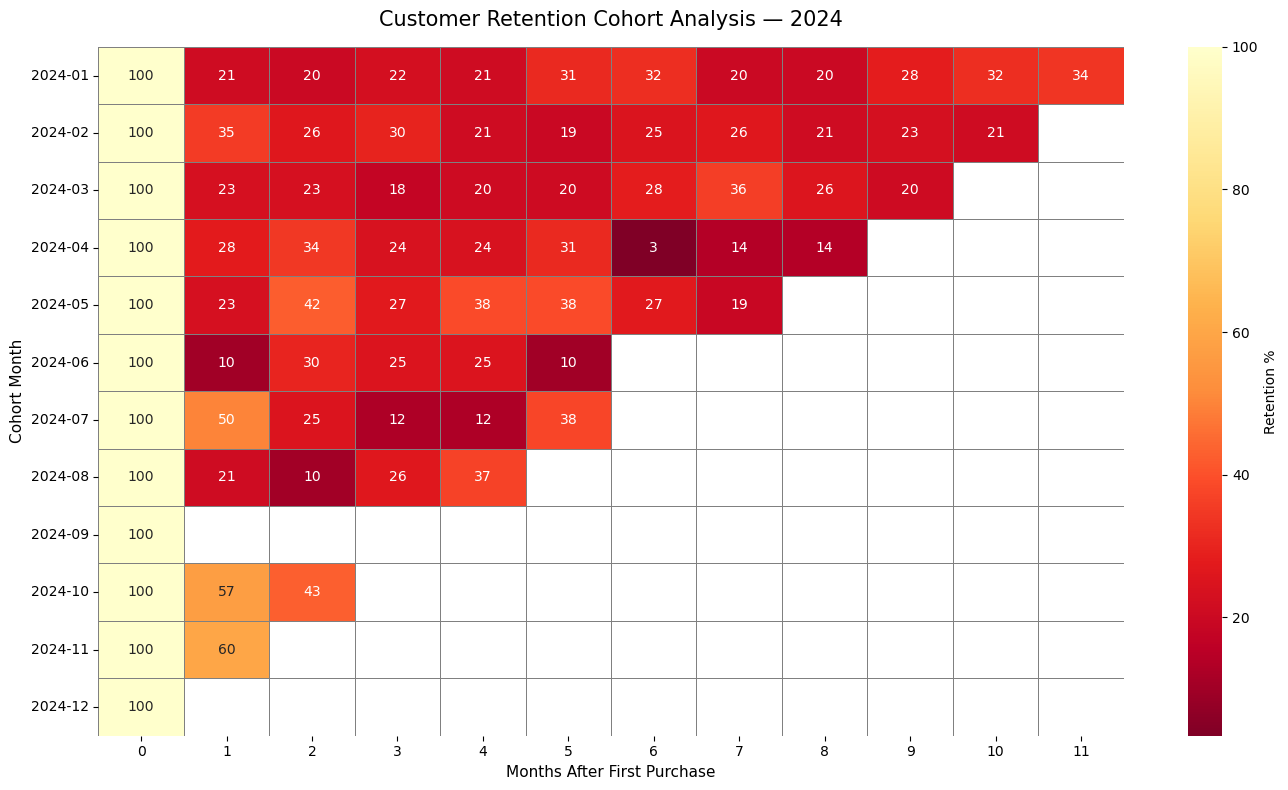

In [18]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_table,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={'label': 'Retention %'}
)

plt.title('Customer Retention Cohort Analysis — 2024', fontsize=15, pad=15)
plt.xlabel('Months After First Purchase', fontsize=11)
plt.ylabel('Cohort Month', fontsize=11)
plt.tight_layout()
plt.savefig('cohort_heatmap.png')
plt.show()

In [19]:
# Average retention per month across all cohorts
avg_retention = retention_table.mean()

print("=== AVERAGE RETENTION BY MONTH ===\n")
for month, ret in avg_retention.items():
    churn = 100 - ret
    print(f"Month {month}: {ret:.1f}% retained — {churn:.1f}% churned")

=== AVERAGE RETENTION BY MONTH ===

Month 0: 100.0% retained — 0.0% churned
Month 1: 32.8% retained — 67.2% churned
Month 2: 28.3% retained — 71.7% churned
Month 3: 23.1% retained — 76.9% churned
Month 4: 24.9% retained — 75.1% churned
Month 5: 26.8% retained — 73.2% churned
Month 6: 23.1% retained — 76.9% churned
Month 7: 23.0% retained — 77.0% churned
Month 8: 20.1% retained — 80.0% churned
Month 9: 23.8% retained — 76.2% churned
Month 10: 26.8% retained — 73.2% churned
Month 11: 33.8% retained — 66.2% churned


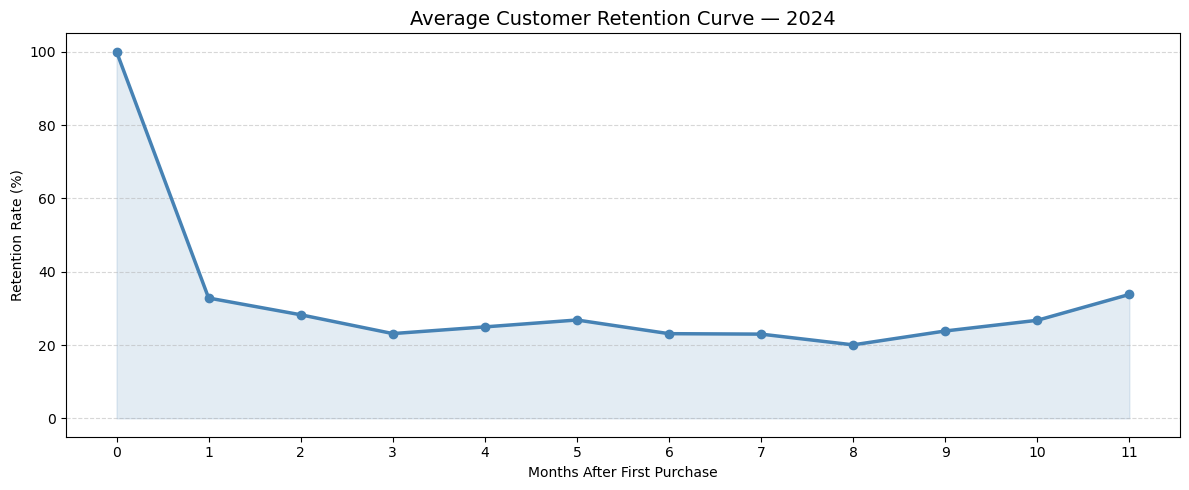

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(avg_retention.index, avg_retention.values,
         marker='o', color='steelblue', linewidth=2.5)
plt.fill_between(avg_retention.index, avg_retention.values,
                 alpha=0.15, color='steelblue')

plt.title('Average Customer Retention Curve — 2024', fontsize=14)
plt.xlabel('Months After First Purchase')
plt.ylabel('Retention Rate (%)')
plt.xticks(avg_retention.index)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('retention_curve.png')
plt.show()